# **LESSON 2 (Resource Allocation Problem):**

By Diego Fiz García

_______________________________________________________________________________________________________________________________________________________

## **Resource Allocation Problem**

#### Context
A farmer owns 100 hectares of land to allocate between wheat and corn. The objective is to maximize profit while considering budget and labor constraints.

#### Decision Variables
- $x_1$: hectares allocated to **wheat**
- $x_2$: hectares allocated to **corn**
- $y$: total profit (to be maximized)

#### Parameters

| Crop  | Profit/ha (€) | Cost/ha (€) | Labor/ha (hours) |
|-------|---------------|-------------|------------------|
| Wheat | 300           | 120         | 10               |
| Corn  | 400           | 200         | 20               |

#### Objective Function
Maximize:
$$y = 300x_1 + 400x_2$$

This function is transformed for optimization using the HiGHS method as:
$$\text{Minimize: } -300x_1 - 400x_2$$

#### Constraints

**1. Land Constraint:**
$$x_1 + x_2 \leq 100$$

**2. Budget Constraint:**
$$120x_1 + 200x_2 \leq 20,000$$

**3. Labor Constraint:**
$$10x_1 + 20x_2 \leq 1,200$$

**4. Non-negativity Constraint:**
$$x_1 \geq 0, \quad x_2 \geq 0$$

#### Optimal Solution
According to the executed code, the optimal solution is:
- $x_1 = 80$ hectares of wheat
- $x_2 = 20$ hectares of corn
- Maximum profit: **€32,000**

#### Active Constraints Analysis

| Constraint | LHS Value | RHS Limit | Slack |
|------------|-----------|-----------|-------|
| Land       | 100       | 100       | 0     |
| Budget     | 13,600    | 20,000    | 6,400 |
| Labor      | 1,200     | 1,200     | 0     |

The **Land** and **Labor** constraints are active (slack = 0), while the **Budget** constraint has a slack of €6,400.

#### Shadow Prices
Shadow prices indicate the increase in profit per additional unit of resource:
- **Land**: €200/hectare
- **Budget**: €0/euro (non-binding resource)
- **Labor**: €10/hour

This means that increasing available land by 1 hectare would increase profit by €200, and increasing available labor hours by 1 hour would increase profit by €10.


### Solution:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import linprog

# =========================
# MODELO BASE
# =========================

# Max 300 x1 + 400 x2  ->  Min -300 x1 - 400 x2 (HiGHS)

c = np.array([-300.0, -400.0])  # minimizar
A_ub = np.array([
    [1,   1],      # Tierra
    [120, 200],    # Presupuesto
    [10,  20]      # Trabajo
], dtype=float)
b_ub = np.array([100.0, 20000.0, 1200.0], dtype=float)
bounds = [(0, None), (0, None)]
names = ["Tierra", "Presupuesto", "Trabajo"]

def solve(b_vec):
    res = linprog(c, A_ub=A_ub, b_ub=b_vec, bounds=bounds, method="highs")
    profit = -res.fun                            # volver a max
    shadow_profit = -res.ineqlin.marginals       # precios sombra de la ganancia
    slack = res.ineqlin.residual                 # holguras
    return res.x, profit, shadow_profit, slack, res

x_base, profit_base, shadow_base, slack_base, res_base = solve(b_ub)
x1, x2 = x_base
print(f"x1 (trigo) = {x1:.0f} ha")
print(f"x2 (maíz)  = {x2:.0f} ha")
print(f"Beneficio  = €{profit_base:.0f}")

# Comprobación de restricciones y holguras (LHS <= RHS)

lhs = A_ub.dot(np.array([x1, x2]))
for name, li, bi in zip(names, lhs, b_ub):
    print(f"{name}: {li:.0f} <= {bi:.0f}  (holgura {bi-li:.0f})")

print("Precios sombra (ganancia) por restricción:", dict(zip(names, shadow_base)))
print("Holguras:", dict(zip(names, slack_base)))

x1 (trigo) = 80 ha
x2 (maíz)  = 20 ha
Beneficio  = €32000
Tierra: 100 <= 100  (holgura 0)
Presupuesto: 13600 <= 20000  (holgura 6400)
Trabajo: 1200 <= 1200  (holgura 0)
Precios sombra (ganancia) por restricción: {'Tierra': 200.0, 'Presupuesto': 0.0, 'Trabajo': 10.0}
Holguras: {'Tierra': 0.0, 'Presupuesto': 6400.0, 'Trabajo': 0.0}


In [ ]:
# =========================
# FUNCIONES GRÁFICO FACTIBLE
# =========================

def line_from_constraint(a1, a2, rhs, xgrid):
    # a1*x1 + a2*x2 = rhs -> x2 = (rhs - a1*x1)/a2
    return (rhs - a1 * xgrid) / a2

def feasible_polygon():
    # Intersecciones de pares de rectas (incluye ejes x1=0 y x2=0)
    lines = [
        (1, 0, 0),            # x1 = 0
        (0, 1, 0),            # x2 = 0
        (1, 1, 100),          # tierra
        (120, 200, 20000),    # presupuesto
        (10, 20, 1200)        # trabajo
    ]
    pts = []
    for i in range(len(lines)):
        for j in range(i+1, len(lines)):
            a1, b1, c1 = lines[i]
            a2, b2, c2 = lines[j]
            det = a1*b2 - a2*b1
            if abs(det) < 1e-12:
                continue
            x = (c1*b2 - c2*b1) / det
            y = (a1*c2 - a2*c1) / det
            # Factibilidad
            if (x >= -1e-9 and y >= -1e-9 and
                x + y <= 100 + 1e-9 and
                120*x + 200*y <= 20000 + 1e-9 and
                10*x + 20*y <= 1200 + 1e-9):
                pts.append([x, y])
    P = np.array(pts)
    ctr = P.mean(axis=0)
    ang = np.arctan2(P[:,1]-ctr[1], P[:,0]-ctr[0])
    return P[np.argsort(ang)]

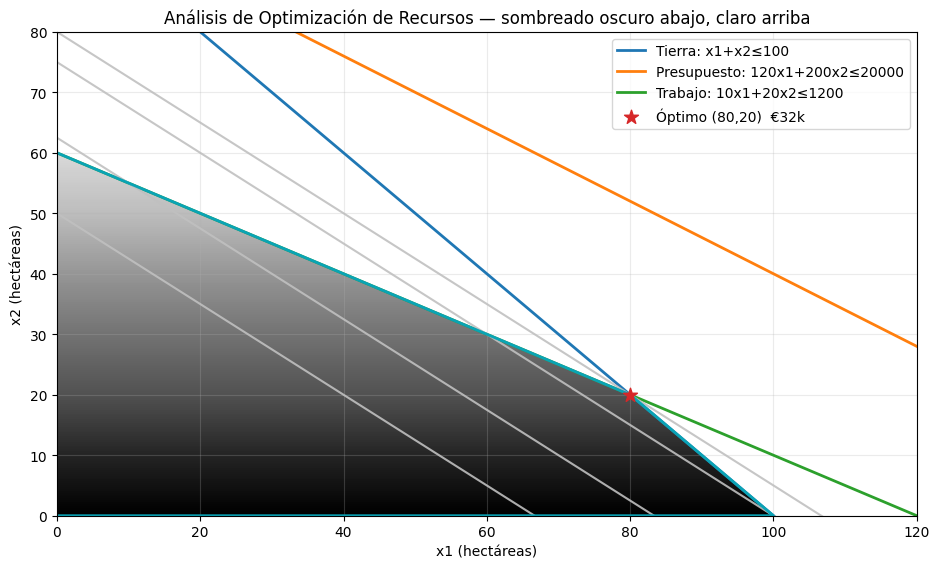

In [ ]:
# =========================
# GRÁFICO DE OPTIMIZACIÓN
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import linprog
from linear_programming_setup import solve, feasible_polygon, line_from_constraint

xmax, ymax = 120, 80
x = np.linspace(0, xmax, 400)

fig, ax = plt.subplots(figsize=(9.5, 5.8))

# Degradado vertical (1 abajo -> 0 arriba) y recorte al polígono factible
grad = np.linspace(1, 0, 256).reshape(256, 1)  # oscuro abajo, claro arriba
im = ax.imshow(grad, extent=(0, xmax, 0, ymax),
               origin='lower', cmap='Greys', aspect='auto', zorder=0)
poly = feasible_polygon()
clip_patch = Polygon(poly, closed=True, facecolor='none', edgecolor='none', transform=ax.transData)
im.set_clip_path(clip_patch)

# Líneas de restricción
ax.plot(x, line_from_constraint(1, 1, 100, x), lw=2.0, color="#1f77b4", label="Tierra: x1+x2≤100")
ax.plot(x, line_from_constraint(120, 200, 20000, x), lw=2.0, color="#ff7f0e", label="Presupuesto: 120x1+200x2≤20000")
ax.plot(x, line_from_constraint(10, 20, 1200, x), lw=2.0, color="#2ca02c", label="Trabajo: 10x1+20x2≤1200")

# Isobeneficio (incluye óptimo)
for p in [20000, 25000, 30000, profit_base]:
    ax.plot(x, (p - 300*x)/400, color='silver', lw=1.5, alpha=0.9)

# Contorno del polígono factible
ax.plot(*poly.T, color="#0aa3b5", lw=2.0)

# Punto óptimo
ax.scatter([x1], [x2], s=110, marker='*', color='#d62728', zorder=3,
           label=f"Óptimo ({x1:.0f},{x2:.0f})  €{profit_base/1000:.0f}k")

ax.set_xlim(0, xmax)
ax.set_ylim(0, ymax)
ax.set_xlabel("x1 (hectáreas)")
ax.set_ylabel("x2 (hectáreas)")
ax.set_title("Análisis de Optimización de Recursos — sombreado oscuro abajo, claro arriba")
ax.legend(loc="upper right", frameon=True)
ax.grid(True, alpha=0.25)
fig.tight_layout()
fig.savefig("optim_recursos.png", dpi=180)

In [ ]:
# =========================
# ANÁLISIS DE SENSIBILIDAD
# =========================

from pandas import pd
from numpy import np

rows = []
for i, name in enumerate(names):
    grid = np.linspace(0.5*b_ub[i], 1.5*b_ub[i], 41)
    for bval in grid:
        btest = b_ub.copy()
        btest[i] = bval
        x, profit, shadow, slack, r = solve(btest)
        rows.append({
            "constraint_index": i,
            "constraint": name,
            "b_value": bval,
            "x1": x[0],
            "x2": x[1],
            "profit": profit,
            "shadow_price": shadow[i],
            "binding": abs(slack[i]) < 1e-8,
            "slack": slack[i]
        })

df = pd.DataFrame(rows)
df.to_csv("sensibilidades_RHS.csv", index=False)
print("CSV escrito: sensibilidades_RHS.csv")

# Rango local de validez del precio sombra (constancia alrededor del RHS base)
def rango_validez_local(dfc, b0, sp0, tol_sp=1e-6):
    same_sp = dfc[np.isclose(dfc["shadow_price"], sp0, atol=tol_sp)]
    if same_sp.empty:
        return (np.nan, np.nan)
    left = same_sp[same_sp["b_value"] <= b0]["b_value"].max()
    right = same_sp[same_sp["b_value"] >= b0]["b_value"].min()
    if np.isnan(left): left = b0
    if np.isnan(right): right = b0
    return (left, right)

rangos = []
for i, name in enumerate(names):
    dfi = df[df["constraint_index"] == i].copy()
    l, r = rango_validez_local(dfi, b_ub[i], shadow_base[i])
    rangos.append({"constraint": name, "rhs_base": b_ub[i],
                   "shadow_base": shadow_base[i],
                   "rhs_valid_min": l, "rhs_valid_max": r})
pd.DataFrame(rangos).to_csv("rangos_locales_precios_sombra.csv", index=False)
print("CSV escrito: rangos_locales_precios_sombra.csv")

CSV escrito: sensibilidades_RHS.csv
CSV escrito: rangos_locales_precios_sombra.csv


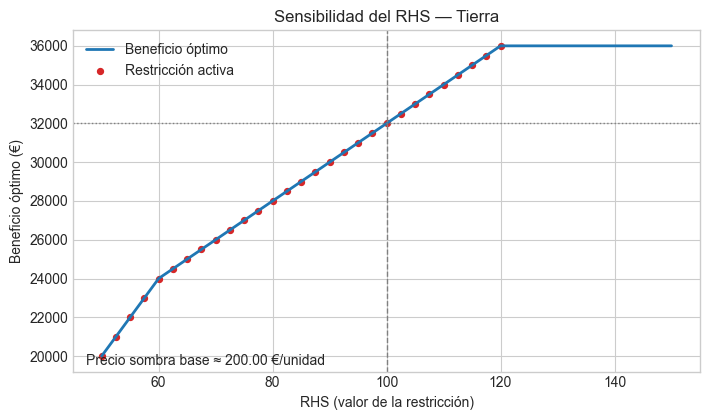

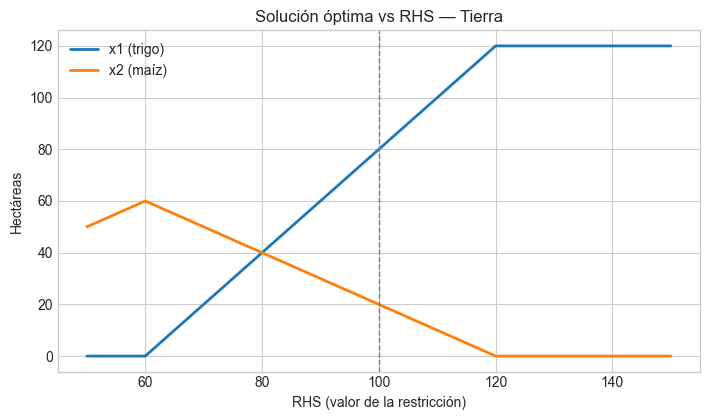

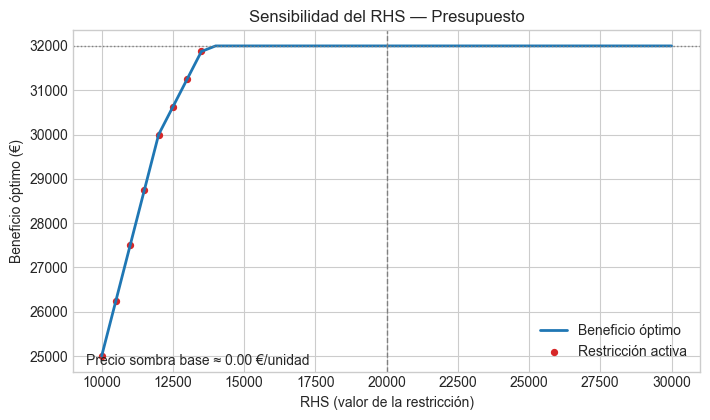

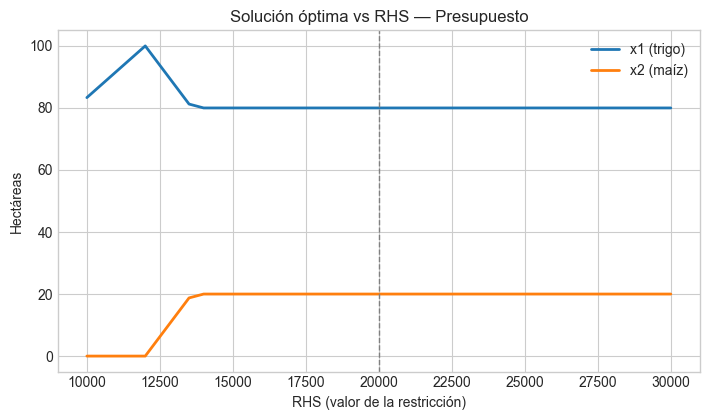

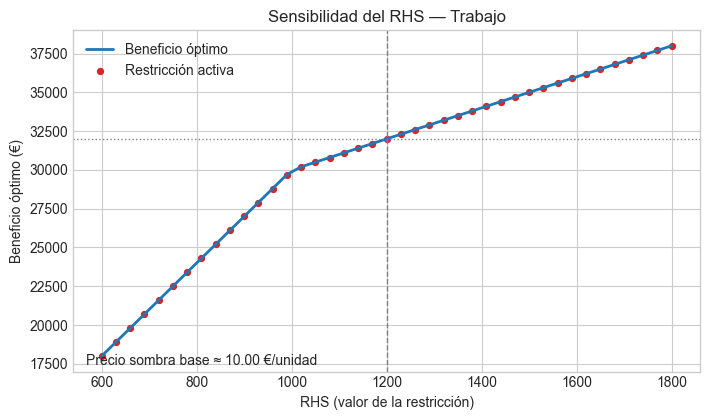

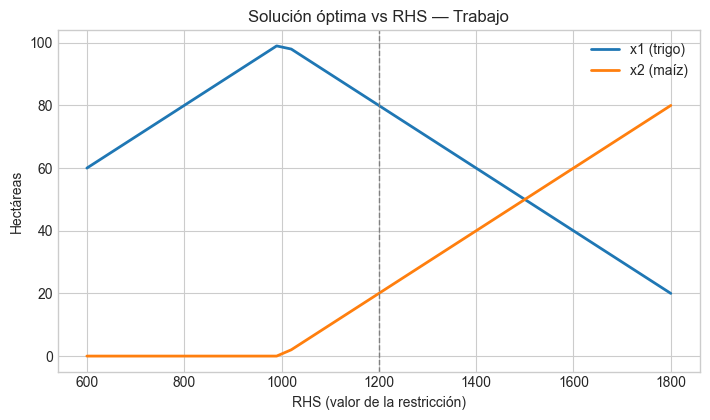

In [ ]:
# =========================
# GRÁFICOS DE SENSIBILIDAD
# =========================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
for i, name in enumerate(names):
    dfi = df[df["constraint_index"] == i].copy()
    b0 = b_ub[i]
    sp0 = shadow_base[i]

    fig, ax = plt.subplots(figsize=(7.2, 4.3))
    ax.plot(dfi["b_value"], dfi["profit"], color="#1f77b4", lw=2, label="Beneficio óptimo")
    ax.scatter(dfi.loc[dfi["binding"], "b_value"], dfi.loc[dfi["binding"], "profit"],
               s=18, color="#d62728", label="Restricción activa")
    ax.axvline(b0, color="gray", ls="--", lw=1)
    ax.axhline(profit_base, color="gray", ls=":", lw=1)
    ax.set_title(f"Sensibilidad del RHS — {name}")
    ax.set_xlabel("RHS (valor de la restricción)")
    ax.set_ylabel("Beneficio óptimo (€)")
    ax.legend(loc="best")
    ax.text(0.02, 0.02, f"Precio sombra base ≈ {sp0:.2f} €/unidad", transform=ax.transAxes)
    fig.tight_layout()
    fig.savefig(f"sens_{i}_{name}_beneficio.png", dpi=160)

    fig2, ax2 = plt.subplots(figsize=(7.2, 4.3))
    ax2.plot(dfi["b_value"], dfi["x1"], lw=2, label="x1 (trigo)")
    ax2.plot(dfi["b_value"], dfi["x2"], lw=2, label="x2 (maíz)")
    ax2.axvline(b0, color="gray", ls="--", lw=1)
    ax2.set_title(f"Solución óptima vs RHS — {name}")
    ax2.set_xlabel("RHS (valor de la restricción)")
    ax2.set_ylabel("Hectáreas")
    ax2.legend(loc="best")
    fig2.tight_layout()
    fig2.savefig(f"sens_{i}_{name}_x.png", dpi=160)

plt.show()